**STEP 1 — Import Necessary Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LinearRegression
from scipy.stats import f_oneway

sns.set(style="whitegrid")

**STEP 2 — Load the Wine Datase**

In [ ]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

** STEP 3 — Display Dataset Information**

In [ ]:
print("Shape of dataset:", df.shape)
print(df.info())
df.describe()

Shape of dataset: (178, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 no

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


**STEP 4 — Check for Missing Values**

In [ ]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


**STEP 5 — Correlation Analysis (Heatmap)**

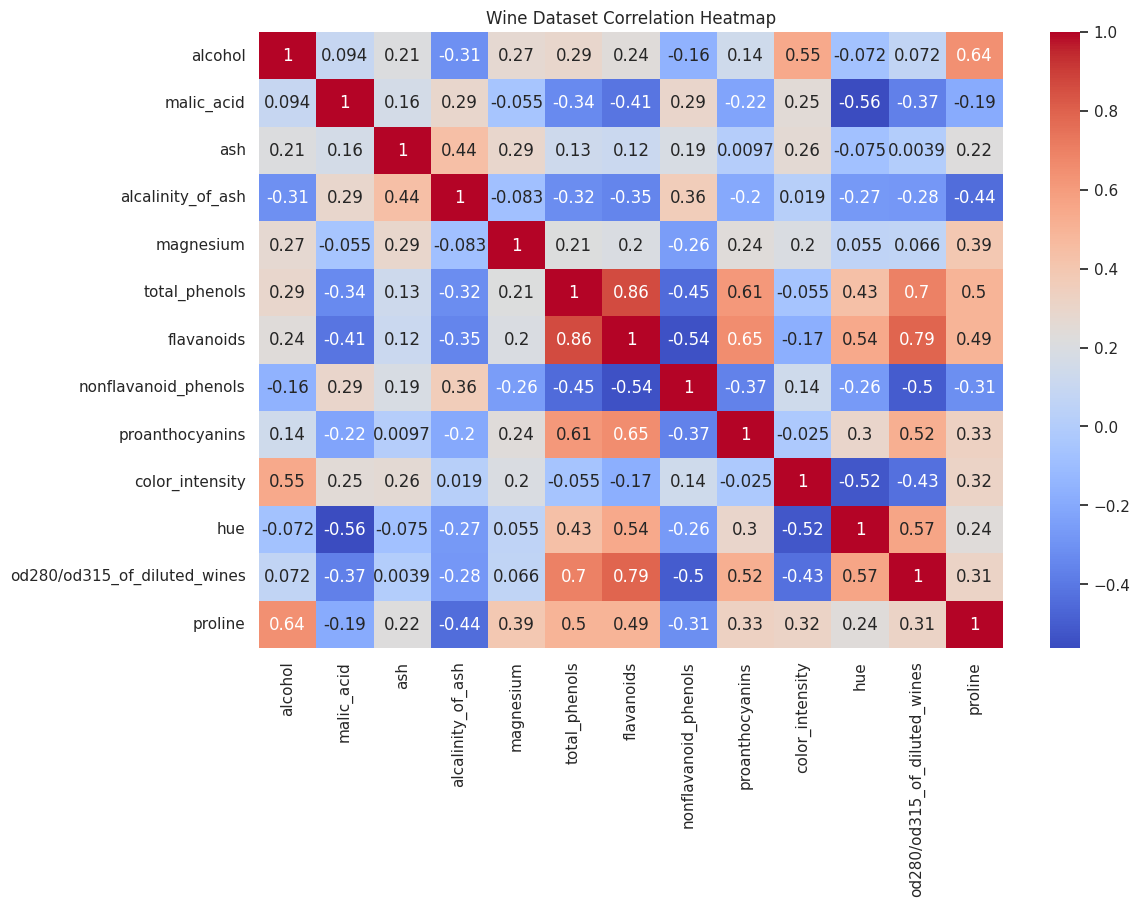

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Wine Dataset Correlation Heatmap")
plt.show()

**STEP 6 — Apply PCA (Principal Component Analysis)**

In [ ]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df)

**STEP 7 — PCA Visualization**

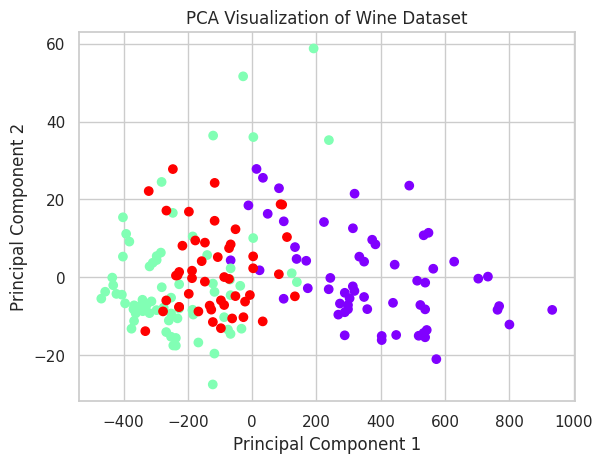

In [ ]:
plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=wine.target,
    cmap='rainbow'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Wine Dataset")
plt.show()

**LDA — LINEAR DISCRIMINANT ANALYSIS**

**STEP 8 — Prepare Data for LDA**

In [ ]:
features = wine.data
target = wine.target

**STEP 9 — Apply LDA**

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=2)
lda_transformed = lda.fit_transform(features, target)


**STEP 10 — LDA Visualization**

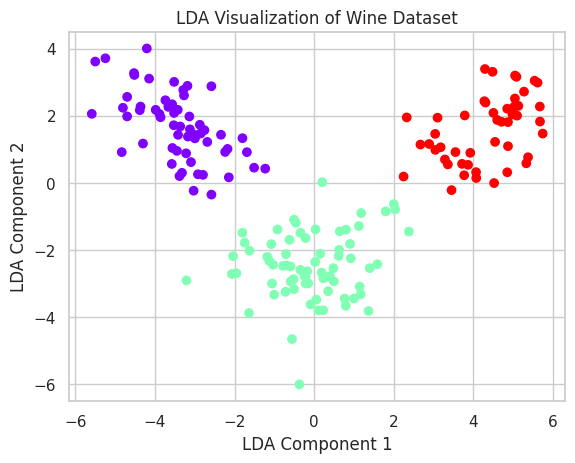

In [ ]:
plt.scatter(
    lda_transformed[:, 0],
    lda_transformed[:, 1],
    c=target,
    cmap='rainbow'
)
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("LDA Visualization of Wine Dataset")
plt.show()

**REGRESSION ANALYSIS**

**STEP 11 — Simple Linear Regression**

*   List item Alcohol vs Malic Acid relation




In [ ]:
X = df[['alcohol']]
y = df['malic_acid']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

**STEP 12 — Regression Visualization**

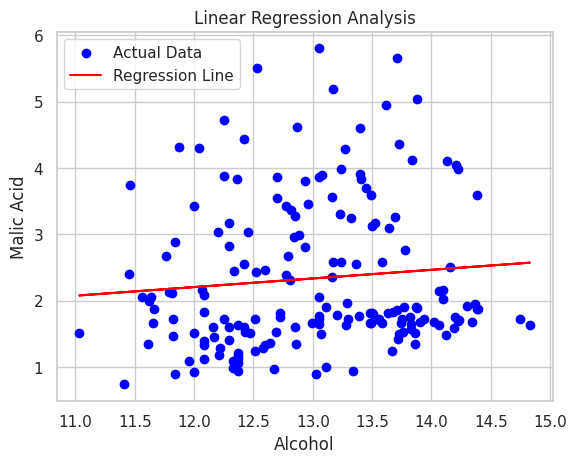

In [ ]:
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.title("Linear Regression Analysis")
plt.legend()
plt.show()

**ANOVA — ANALYSIS OF VARIANCE**

**STEP 13 — Add Target Column**

In [ ]:
df['target'] = wine.target

**STEP 14 — Perform One-Way ANOVA Test**

In [ ]:
class0 = df[df['target'] == 0]['alcohol']
class1 = df[df['target'] == 1]['alcohol']
class2 = df[df['target'] == 2]['alcohol']

f_stat, p_value = f_oneway(class0, class1, class2)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 135.07762424279917
P-value: 3.319503795619573e-36


**Interpretation:**

*   List item p < 0.05 → significant difference exists
*   List item p ≥ 0.05 → no significant difference



**STEP 15 —  ANOVA Visualization**

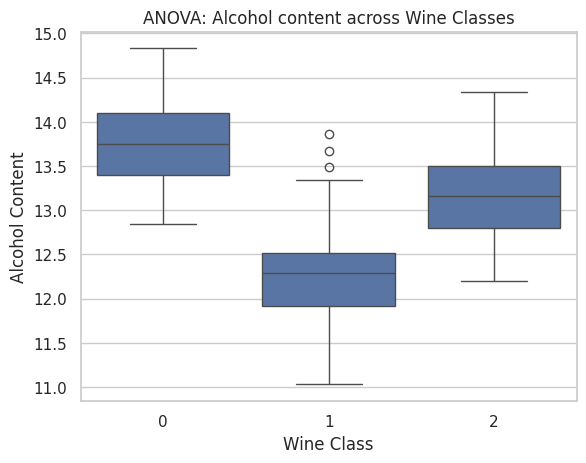

In [ ]:
sns.boxplot(x='target', y='alcohol', data=df)
plt.xlabel("Wine Class")
plt.ylabel("Alcohol Content")
plt.title("ANOVA: Alcohol content across Wine Classes")
plt.show()